#Prohlášení
Tento notebook slouží ke trénování modelů s architekturou LiLT a byl vytvořen z velké části na základě noteboků Nielse Rogge, repozitář: https://github.com/NielsRogge/Transformers-Tutorials

#Nastavení proměnných prostředí

In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
FINETUNED_MODEL_ID = "TomasFAV/LiLTInvoiceCzechV01"
BASE_MODEL_ID = "TomasFAV/LiLTInvoiceCzechV0"
#BASE_MODEL_ID = "SCUT-DLVCLab/lilt-roberta-en-base"

In [2]:
!pip install -q evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


#Načtení datasetů

In [3]:
from datasets import load_dataset

train_dataset = load_dataset("TomasFAV/DocumentInvoiceCzechNameEntityRecognitionV1", split="train")
val_dataset = load_dataset("TomasFAV/RealDocumentInvoiceCzechNameEntityRecognition", split="train") #jedná se o dataset skutečných faktur anotovaných pro NER úlohu

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/600 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39 [00:00<?, ? examples/s]

#Vytvoření Id2Label
Pro vytvoření slovníku spoléhá na Speciální typ dat v huggingface(ClassLabel),
který jsem použil při vytváření datasetu

In [4]:
from datasets.features import ClassLabel

features = train_dataset.features
column_names = train_dataset.column_names
label_column_name = "ner_tags"

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}

#Načtení processoru a modelu

In [5]:
from transformers import AutoProcessor
from transformers import LiltForTokenClassification

processor = AutoProcessor.from_pretrained(BASE_MODEL_ID, apply_ocr=False)
model = LiltForTokenClassification.from_pretrained(BASE_MODEL_ID,
                                                         num_labels=len(label_list),
                                                         id2label=id2label,
                                                         label2id=label2id).to(device)

tokenizer_config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/521M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

# Overfit
Slouží ke kontrole, že se model správně učí

In [6]:
#x = 30
#train_dataset = train_dataset.select(range(x))
#val_dataset = val_dataset.select(range(x))
#train_dataset

#Vizualizace dat
Slouží k ověření správnosti datasetu

In [7]:
from PIL import ImageDraw, ImageFont, Image
import random

In [8]:
item = val_dataset[3]

In [9]:
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n))) #vygeneruje pro jednotlivé třídy random barvy
colors = get_colors(len(label_list))
font = ImageFont.load_default()
label2color = {label: colors[idx] for idx, label in enumerate(label_list)}

In [10]:
image = item["image"]
ner_tags = item["ner_tags"]
tokens = item["tokens"]
boxes = item["bboxes"]

In [11]:
draw_1 = ImageDraw.Draw(image)

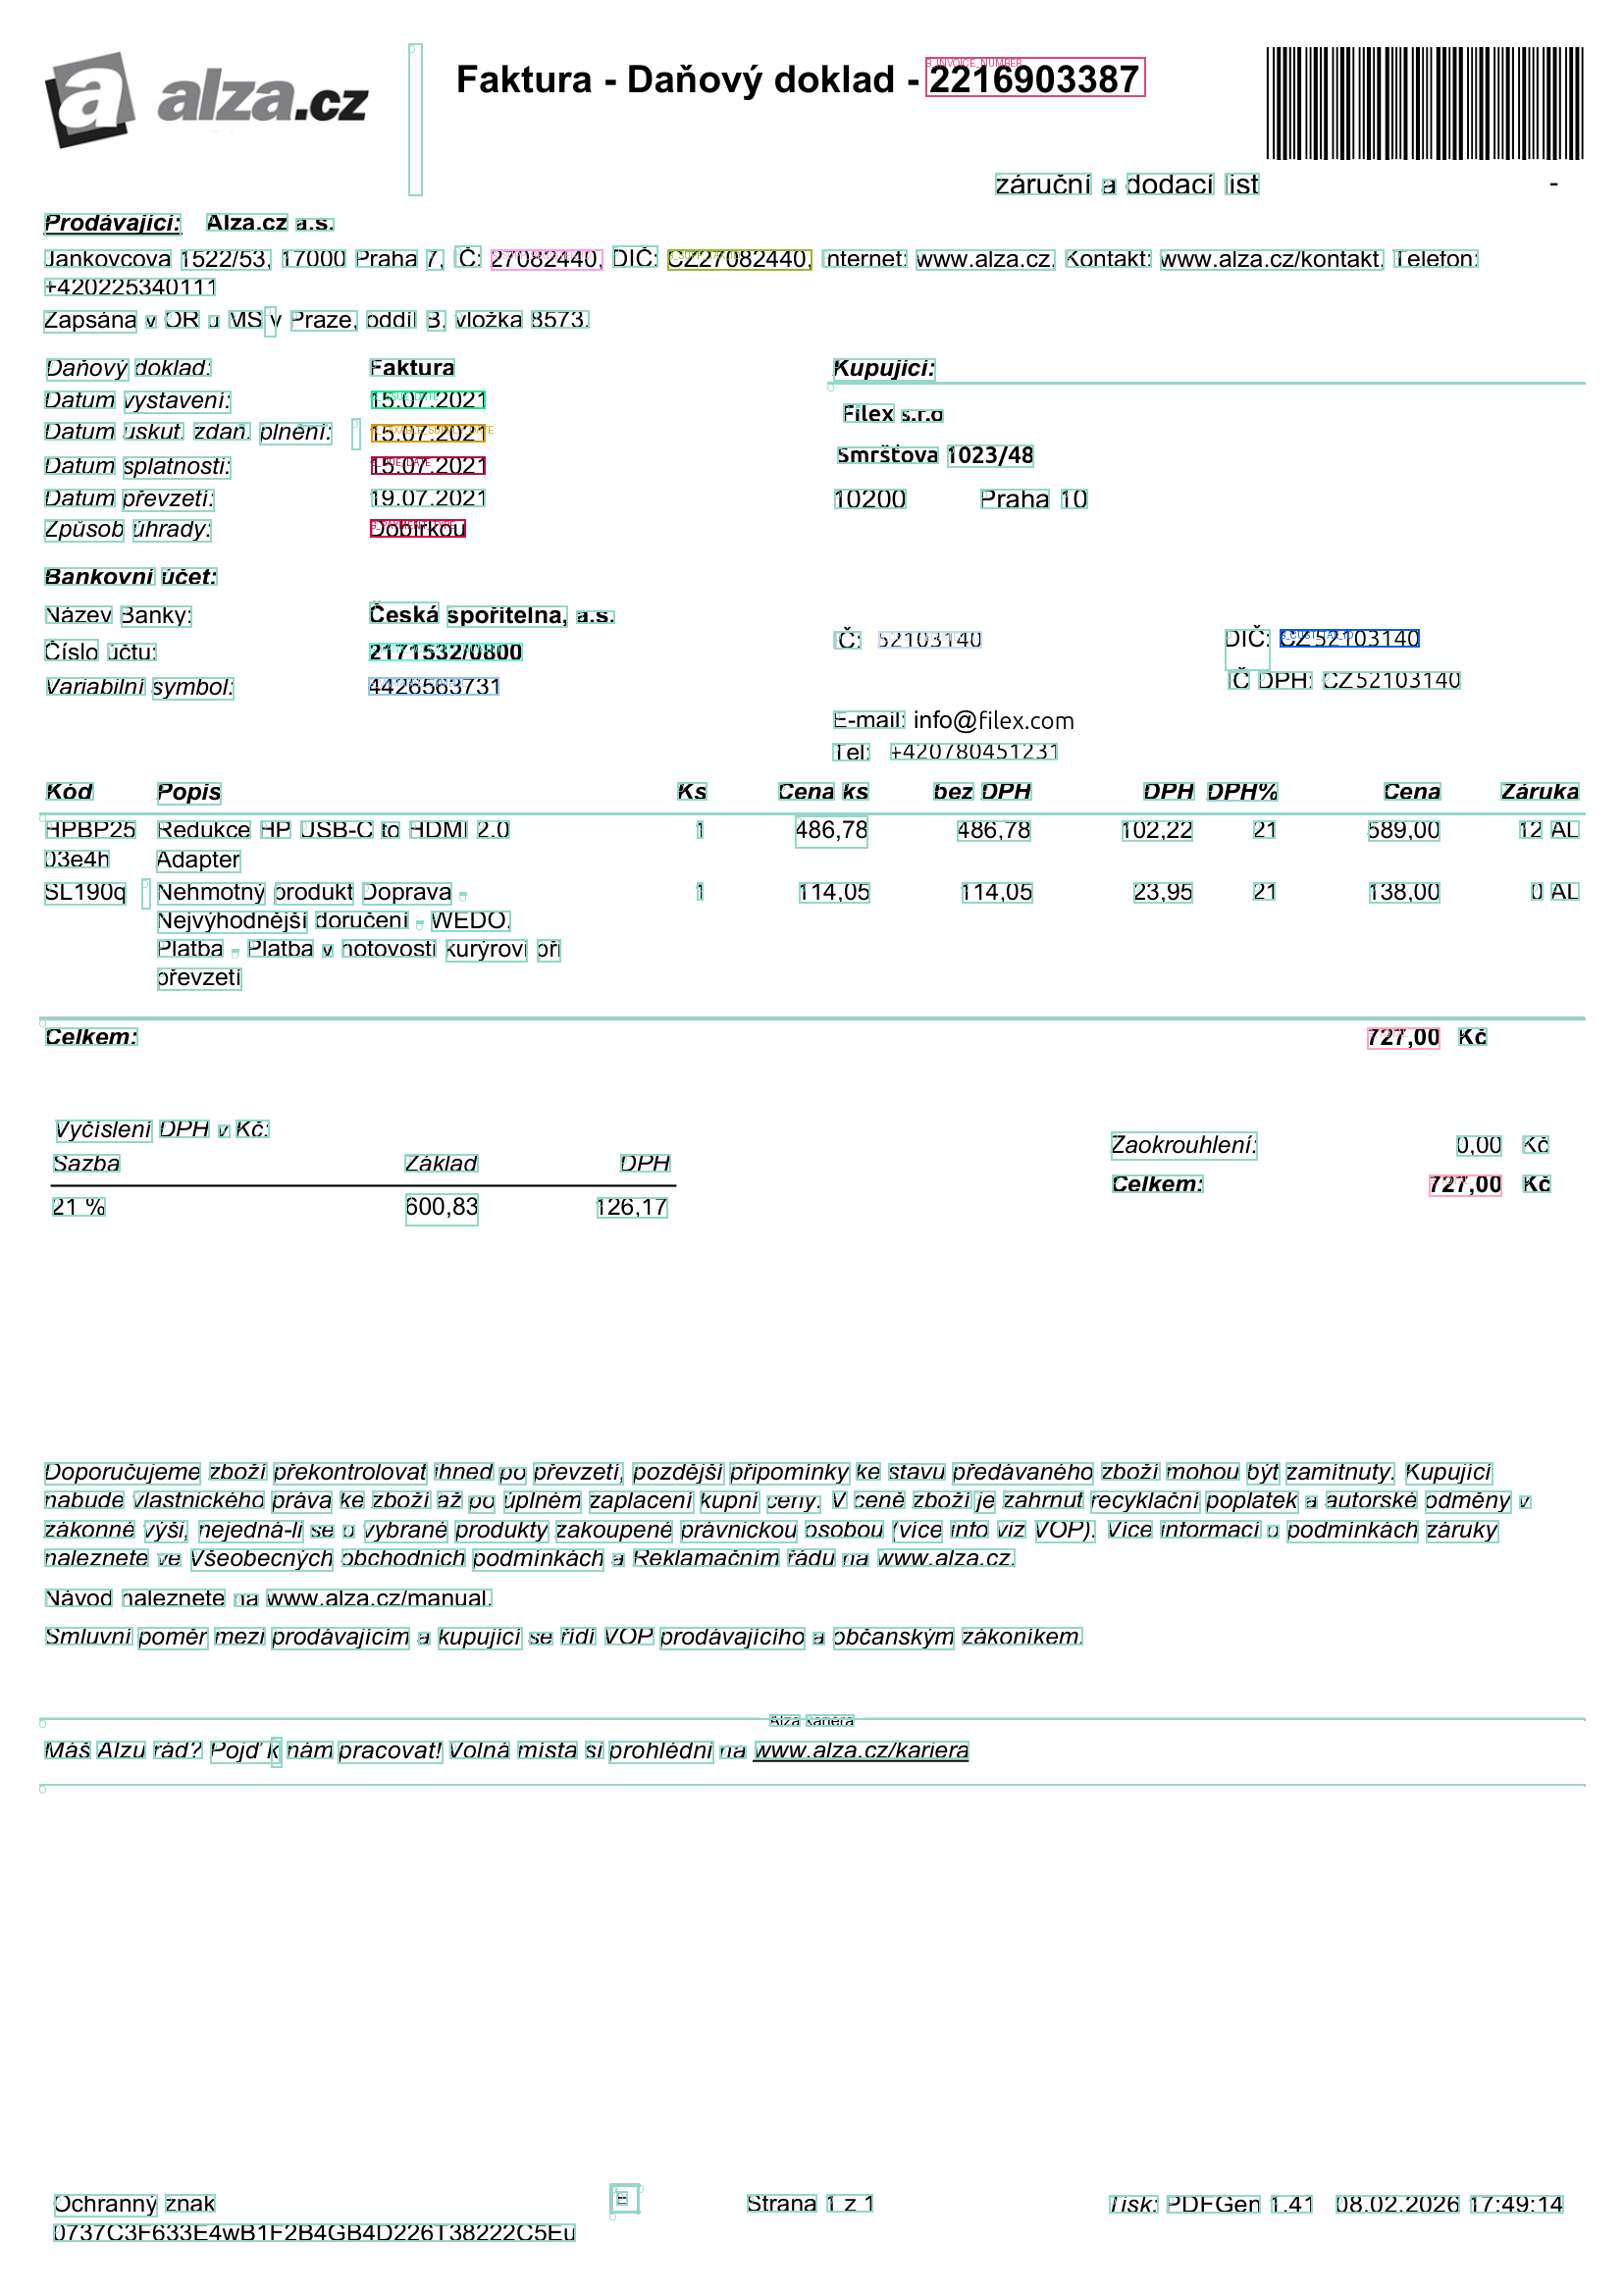

In [12]:
# We are visulizing boxes on original imag
for label_id, box in zip(ner_tags, boxes):
    x1, y1, x2, y2 = box
    box = [x1, y1, x2, y2]

    draw_1.rectangle(box, outline=label2color[id2label[label_id]], width=2)
    draw_1.text((box[0], box[1]), id2label[label_id], fill=label2color[id2label[label_id]], font=font, size=20)

image

# Collator funkce

In [13]:
import torch

def collate(batch):
  images = [item["image"] for item in batch]
  tokens = [item["tokens"] for item in batch]
  boxes = [item["bboxes"] for item in batch] #POZOR nejsou normalizované, jsou v rozsahu x:<0, šířka obrázku>, y:<0, výška obrázku>
  ner_tags = [item["ner_tags"] for item in batch]

  normalized_bboxes = []
  for item_idx, item_boxes in enumerate(boxes):
    W, H = images[item_idx].size #vezmu si rozměry aktuálního obrázku
    doc_boxes = []
    for box in item_boxes:
      # box = [x1, y1, x2, y2]
      normalized_box = [
        int(1000 * (box[0] / W)),
        int(1000 * (box[1] / H)),
        int(1000 * (box[2] / W)),
        int(1000 * (box[3] / H))
      ]
      # Ošetření clippingu (0-1000)
      normalized_box = [max(0, min(1000, c)) for c in normalized_box]
      doc_boxes.append(normalized_box)
    normalized_bboxes.append(doc_boxes)

  encoding = processor(tokens, boxes=normalized_bboxes,
                         max_length=512, padding="max_length", stride=128, truncation=True,
                         return_overflowing_tokens=True, return_offsets_mapping = True,
                       is_split_into_words=True, return_tensors="pt")

  # Ruční vytvoření labelů, problém když se používá processor
  labels = []
  for i in range(encoding["input_ids"].shape[0]):
      word_ids = encoding.word_ids(batch_index=i)
      previous_word_idx = None
      label_ids = []
      for word_idx in word_ids:
          if word_idx is None: # Speciální token
              label_ids.append(-100) #-100 ignore_id
          elif word_idx != previous_word_idx: #Začátek nového slova
              # Mapování původního NER tagu k prvnímu tokenu slova
              sample_idx = encoding["overflow_to_sample_mapping"][i]
              label_ids.append(ner_tags[sample_idx][word_idx])
          else:
              label_ids.append(-100) # Labeluji pouze první token slova
          previous_word_idx = word_idx
      labels.append(label_ids)
  encoding["labels"] = torch.tensor(labels, dtype=torch.long)


  encoding.pop('offset_mapping')
  encoding.pop('overflow_to_sample_mapping')

  return encoding

In [14]:
test = collate([train_dataset[0]])

#Výpočet metrik pro lepší porovnání epoch

In [15]:
from evaluate import load
metric = load("seqeval")

In [16]:
import numpy as np

return_entity_level_metrics = False

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    if return_entity_level_metrics:
        # Unpack nested dictionaries
        final_results = {}
        for key, value in results.items():
            if isinstance(value, dict):
                for n, v in value.items():
                    final_results[f"{key}_{n}"] = v
            else:
                final_results[key] = value
        return final_results
    else:
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
            "accuracy": results["overall_accuracy"],
        }


#Trénink s HUGGINGFACE API

In [17]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
                                    num_train_epochs=10,

                                    save_total_limit=2,
                                    output_dir=FINETUNED_MODEL_ID,
                                    per_device_train_batch_size=16,               # Batch size for training
                                    per_device_eval_batch_size=2,                # Batch size for evaluation
                                    learning_rate=3e-5,                          # Learning rate for the optimizer


                                    eval_strategy="epoch",
                                    save_strategy="epoch",

                                    load_best_model_at_end=True,                 # Load the best model when finished training
                                    metric_for_best_model="f1",            # Use accuracy as the metric to compare models
                                    greater_is_better = True,                     # Indicate whether the metric is to be maximized or minimized
                                    warmup_ratio=0.1, # we warmup a bit
                                    fp16=True, # we use mixed precision (less memory consumption)

                                    push_to_hub=True, # after training, we'd like to push our model to the hub
                                    hub_model_id=FINETUNED_MODEL_ID, # this is the name we'll use for our model on the hub,
                                    report_to="tensorboard",
                                    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
from transformers.data.data_collator import default_data_collator

# Initialize our Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate,
    compute_metrics=compute_metrics,
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.166467,0.486072,0.595563,0.535276,0.955721
2,No log,0.177138,0.511774,0.556314,0.533115,0.960228
3,No log,0.185776,0.534508,0.621160,0.574586,0.961651
4,No log,0.177765,0.552239,0.568259,0.560135,0.964418
5,No log,0.184601,0.536892,0.583618,0.559280,0.963391
6,No log,0.191760,0.546828,0.617747,0.580128,0.961730
7,No log,0.193442,0.533040,0.619454,0.573007,0.962284
8,No log,0.197673,0.528384,0.619454,0.570306,0.960860
9,No log,0.203789,0.540984,0.619454,0.577566,0.962521
10,No log,0.200868,0.535232,0.609215,0.569832,0.962284


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lilt.embeddings.LayerNorm.weight', 'lilt.embeddings.LayerNorm.bias', 'lilt.layout_embeddings.LayerNorm.weight', 'lilt.layout_embeddings.LayerNorm.bias', 'lilt.encoder.layer.0.attention.output.LayerNorm.weight', 'lilt.encoder.layer.0.attention.output.LayerNorm.bias', 'lilt.encoder.layer.0.attention.layout_output.LayerNorm.weight', 'lilt.encoder.layer.0.attention.layout_output.LayerNorm.bias', 'lilt.encoder.layer.0.output.LayerNorm.weight', 'lilt.encoder.layer.0.output.LayerNorm.bias', 'lilt.encoder.layer.0.layout_output.LayerNorm.weight', 'lilt.encoder.layer.0.layout_output.LayerNorm.bias', 'lilt.encoder.layer.1.attention.output.LayerNorm.weight', 'lilt.encoder.layer.1.attention.output.LayerNorm.bias', 'lilt.encoder.layer.1.attention.layout_output.LayerNorm.weight', 'lilt.encoder.layer.1.attention.layout_output.LayerNorm.bias', 'lilt.encoder.layer.1.output.LayerNorm.weight', 'lilt.encoder.layer.1.output.LayerNorm.bias', 'lilt.enc

TrainOutput(global_step=380, training_loss=0.01563225921831633, metrics={'train_runtime': 478.0036, 'train_samples_per_second': 12.552, 'train_steps_per_second': 0.795, 'total_flos': 3118840440391680.0, 'train_loss': 0.01563225921831633, 'epoch': 10.0})

#EVALUACE
Nutné kvůli automatickému vytvoření model card na huggingface hubu

In [20]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

{'eval_loss': 0.19190606474876404,
 'eval_precision': 0.546969696969697,
 'eval_recall': 0.6160409556313993,
 'eval_f1': 0.5794542536115571,
 'eval_accuracy': 0.9617300545583933,
 'eval_runtime': 3.3381,
 'eval_samples_per_second': 11.683,
 'eval_steps_per_second': 5.991,
 'epoch': 10.0}

# PUSH TO HUB

In [21]:
trainer.save_model(FINETUNED_MODEL_ID)
processor.save_pretrained(FINETUNED_MODEL_ID)

# Save processor and create model card
trainer.create_model_card()
trainer.push_to_hub()
processor.push_to_hub(repo_id=FINETUNED_MODEL_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...echV01R/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

...

  ...175081.82dfeb3f21d8.748.0: 100%|##########| 11.1kB / 11.1kB            

  ...echV01R/model.safetensors:  31%|###       |  160MB /  521MB            

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/TomasFAV/LiLTInvoiceCzechV01R/commit/7fb9e1145abc538cd1f0b32c0395481e1d442ce6', commit_message='Upload tokenizer', commit_description='', oid='7fb9e1145abc538cd1f0b32c0395481e1d442ce6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/TomasFAV/LiLTInvoiceCzechV01R', endpoint='https://huggingface.co', repo_type='model', repo_id='TomasFAV/LiLTInvoiceCzechV01R'), pr_revision=None, pr_num=None)

In [22]:
from google.colab import runtime
runtime.unassign()